# Part 4 - Conceptual Foundations


## Central Limit Theorem

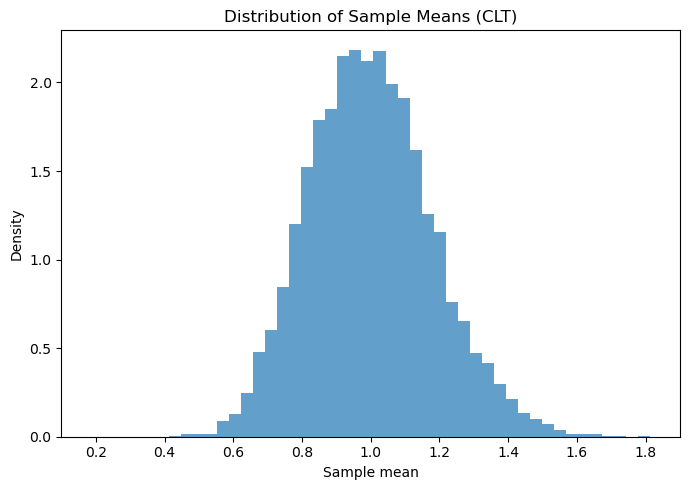

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Generate skewed data (exponential distribution)
n_samples = 10000
sample_size = 30

means = []

for _ in range(n_samples):
    sample = np.random.exponential(scale=1, size=sample_size)
    means.append(np.mean(sample))

plt.figure(figsize=(7,5))
plt.hist(means, bins=40, density=True, alpha=0.7)
plt.xlim(0.1, 1.9)
plt.title("Distribution of Sample Means (CLT)")
plt.xlabel("Sample mean")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("/Figures/clt.pdf", dpi=300, bbox_inches="tight")

plt.show()

Estimated mean (MLE): 5.12


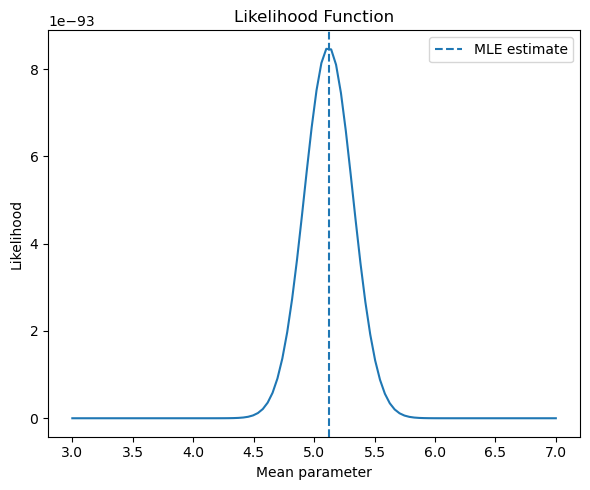

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Generate data
data = np.random.normal(loc=5, scale=2, size=100)

# MLE estimate of mean
mu_hat = np.mean(data)

print(f"Estimated mean (MLE): {mu_hat:.2f}")

# Visualise likelihood for different means
mu_values = np.linspace(3, 7, 100)
likelihoods = []

for mu in mu_values:
    likelihood = np.prod(
        (1 / np.sqrt(2 * np.pi * 2**2)) *
        np.exp(-(data - mu)**2 / (2 * 2**2))
    )
    likelihoods.append(likelihood)

plt.figure(figsize=(6,5))
plt.plot(mu_values, likelihoods)
plt.axvline(mu_hat, linestyle='--', label="MLE estimate")
plt.xlabel("Mean parameter")
plt.ylabel("Likelihood")
plt.title("Likelihood Function")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/mle.pdf", dpi=300, bbox_inches="tight")

plt.show()


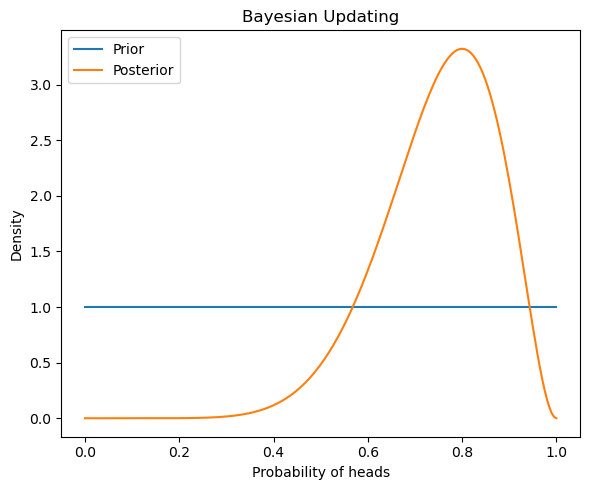

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Prior: Beta(1,1) (uniform)
a_prior, b_prior = 1, 1

# Observed data
heads = 8
tails = 2

# Posterior
a_post = a_prior + heads
b_post = b_prior + tails

x = np.linspace(0, 1, 200)

prior = beta.pdf(x, a_prior, b_prior)
posterior = beta.pdf(x, a_post, b_post)

plt.figure(figsize=(6,5))
plt.plot(x, prior, label="Prior")
plt.plot(x, posterior, label="Posterior")
plt.xlabel("Probability of heads")
plt.ylabel("Density")
plt.title("Bayesian Updating")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/baysian_update.pdf", dpi=300, bbox_inches="tight")

plt.show()

## Probability Foundations

In [ ]:
import numpy as np

# Simulated data: 1 = spam, 0 = not spam
spam = np.random.binomial(1, 0.3, size=1000)

# Word "free" appears more often in spam
free_word = np.where(spam == 1,
                     np.random.binomial(1, 0.6, size=1000),
                     np.random.binomial(1, 0.1, size=1000))

# Compute conditional probability
p_free = np.mean(free_word)
p_spam_and_free = np.mean((spam == 1) & (free_word == 1))

p_spam_given_free = p_spam_and_free / p_free

print(f"P(spam | 'free') ≈ {p_spam_given_free:.2f}")

In [ ]:
# Prior probability of disease
p_disease = 0.01

# Test accuracy
p_positive_given_disease = 0.95
p_positive_given_no_disease = 0.05

# Total probability of positive test
p_positive = (
    p_positive_given_disease * p_disease +
    p_positive_given_no_disease * (1 - p_disease)
)

# Posterior probability
p_disease_given_positive = (
    p_positive_given_disease * p_disease
) / p_positive

print(f"P(disease | positive) ≈ {p_disease_given_positive:.3f}")

## Feature Engineering

In [3]:
import pandas as pd
import numpy as np

# Example dataset
data = pd.DataFrame({
    "price": [200000, 300000, 400000],
    "size": [50, 70, 100]
})

# Feature engineering: price per unit area
data["price_per_m2"] = data["price"] / data["size"]

# Log transformation
data["log_price"] = np.log(data["price"])

print(data)

    price  size  price_per_m2  log_price
0  200000    50   4000.000000  12.206073
1  300000    70   4285.714286  12.611538
2  400000   100   4000.000000  12.899220


In [ ]:
import pandas as pd

data = pd.DataFrame({
    "color": ["red", "blue", "green", "blue"]
})

encoded = pd.get_dummies(data["color"])

print(encoded)

In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Simple example dataset
df = pd.DataFrame({
    "city": ["London", "Paris", "London", "Berlin", "Paris", "Berlin", "London", "Paris"],
    "age": [25, 32, 28, 40, 35, 45, 30, 38],
    "bought": [1, 0, 1, 0, 0, 1, 1, 0]
})

print("Original data:")
print(df)

# ----------------------------
# 1. Label encoding
# ----------------------------
label_encoder = LabelEncoder()
df_label = df.copy()
df_label["city_label"] = label_encoder.fit_transform(df_label["city"])

print("\nLabel encoding:")
print(df_label[["city", "city_label"]])

# ----------------------------
# 2. One-hot encoding
# ----------------------------
onehot_encoder = OneHotEncoder(sparse_output=False)
city_onehot = onehot_encoder.fit_transform(df[["city"]])

df_onehot = pd.DataFrame(
    city_onehot,
    columns=onehot_encoder.get_feature_names_out(["city"])
)

print("\nOne-hot encoding:")
print(df_onehot)

# ----------------------------
# 3. Target encoding
# ----------------------------
# Replace each category by the mean target value for that category
target_means = df.groupby("city")["bought"].mean()
df_target = df.copy()
df_target["city_target"] = df_target["city"].map(target_means)

print("\nTarget encoding:")
print(df_target[["city", "city_target"]])

# ----------------------------
# Combined comparison
# ----------------------------
df_compare = df.copy()
df_compare["city_label"] = label_encoder.transform(df_compare["city"])
df_compare["city_target"] = df_compare["city"].map(target_means)

print("\nComparison table:")
print(df_compare)

print("\nTarget means used for target encoding:")
print(target_means)

Original data:
     city  age  bought
0  London   25       1
1   Paris   32       0
2  London   28       1
3  Berlin   40       0
4   Paris   35       0
5  Berlin   45       1
6  London   30       1
7   Paris   38       0

Label encoding:
     city  city_label
0  London           1
1   Paris           2
2  London           1
3  Berlin           0
4   Paris           2
5  Berlin           0
6  London           1
7   Paris           2

One-hot encoding:
   city_Berlin  city_London  city_Paris
0          0.0          1.0         0.0
1          0.0          0.0         1.0
2          0.0          1.0         0.0
3          1.0          0.0         0.0
4          0.0          0.0         1.0
5          1.0          0.0         0.0
6          0.0          1.0         0.0
7          0.0          0.0         1.0

Target encoding:
     city  city_target
0  London          1.0
1   Paris          0.0
2  London          1.0
3  Berlin          0.5
4   Paris          0.0
5  Berlin          0.5
6  Lo

## Feature Scaling

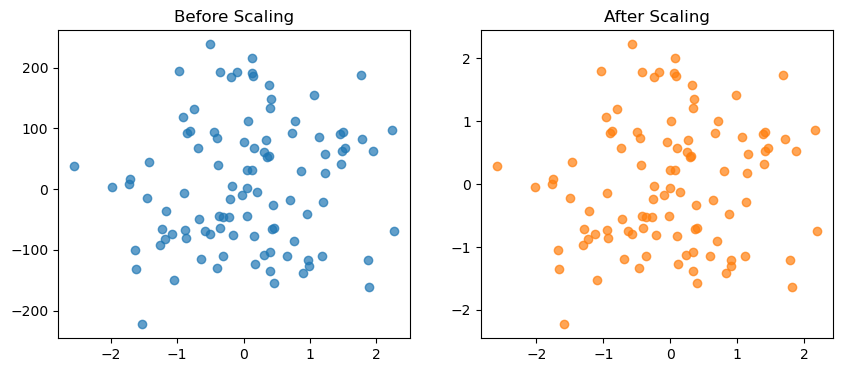

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Create synthetic data
np.random.seed(0)
x1 = np.random.normal(0, 1, 100)
x2 = np.random.normal(0, 100, 100)

X = np.column_stack((x1, x2))

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Plot before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(X[:,0], X[:,1], alpha=0.7)
axes[0].set_title("Before Scaling")
axes[1].scatter(X_scaled[:,0], X_scaled[:,1], color='#ff7f0e', alpha=0.7)
axes[1].set_title("After Scaling")
plt.savefig("/Figures/feature_scaling.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
# Curse of Dimensionality

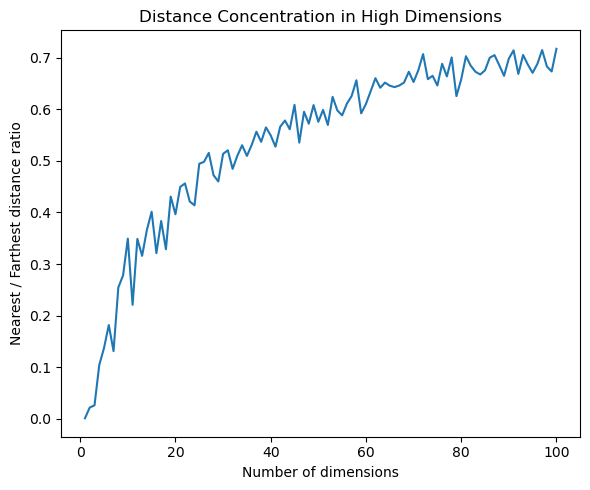

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

dims = range(1, 101)
ratios = []

for d in dims:
    points = np.random.rand(1000, d)
    distances = np.linalg.norm(points - points[0], axis=1)
    min_dist = np.min(distances[1:])
    max_dist = np.max(distances)
    ratios.append(min_dist / max_dist)

plt.figure(figsize=(6,5))
plt.plot(dims, ratios)
plt.xlabel("Number of dimensions")
plt.ylabel("Nearest / Farthest distance ratio")
plt.title("Distance Concentration in High Dimensions")
plt.tight_layout()
plt.savefig("/Figures/curse_dimensionality.pdf", dpi=300, bbox_inches="tight")

plt.show()

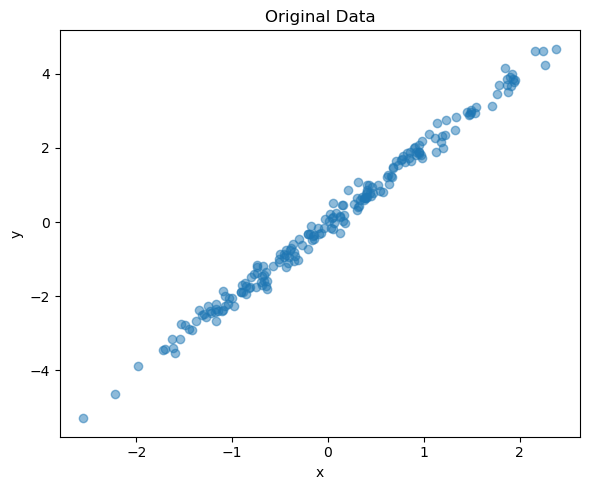

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(0)

# Create correlated data
x = np.random.normal(0, 1, 200)
y = 2 * x + np.random.normal(0, 0.2, 200)

X = np.column_stack((x, y))

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot original data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], alpha=0.5)
plt.title("Original Data")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.savefig("/Figures/pca.pdf", dpi=300, bbox_inches="tight")

plt.show()

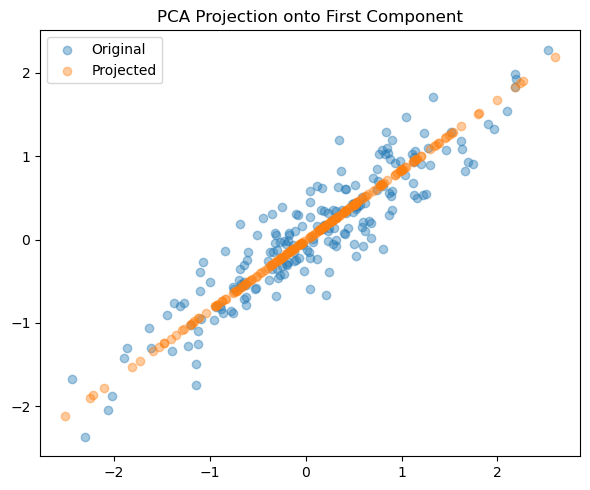

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(1)

# Generate correlated data
x = np.random.normal(0, 1, 200)
y = 0.8 * x + np.random.normal(0, 0.3, 200)

X = np.column_stack((x, y))

# Fit PCA
pca = PCA(n_components=1)
X_reduced = pca.fit_transform(X)
X_reconstructed = pca.inverse_transform(X_reduced)

# Plot original and reconstructed data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], alpha=0.4, label="Original")
plt.scatter(X_reconstructed[:,0], X_reconstructed[:,1],
            alpha=0.4, label="Projected")
plt.legend()
plt.title("PCA Projection onto First Component")
plt.tight_layout()
plt.savefig("/Figures/pca_2.pdf", dpi=300, bbox_inches="tight")

plt.show()

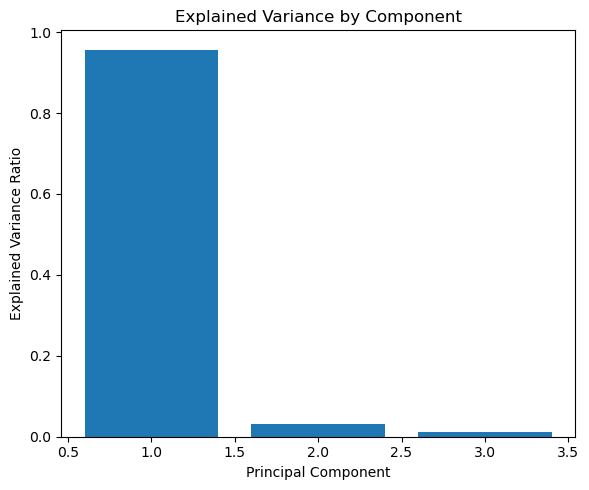

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(0)

# Generate correlated data
X = np.random.randn(200, 3)
X[:,1] = X[:,0] * 0.8 + np.random.randn(200) * 0.2
X[:,2] = X[:,0] * 0.5 + np.random.randn(200) * 0.3

# Apply PCA
pca = PCA()
pca.fit(X)

explained = pca.explained_variance_ratio_

plt.figure(figsize=(6,5))
plt.bar(range(1, len(explained)+1), explained)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Component")
plt.tight_layout()
plt.show()

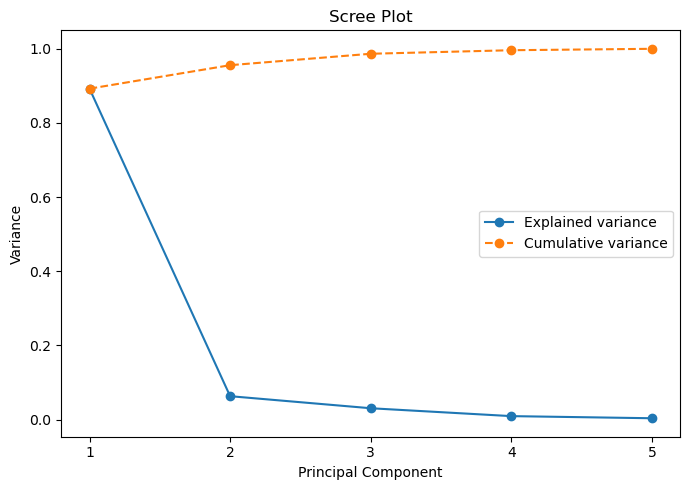

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(0)

# Generate correlated data
X = np.random.randn(300, 5)
X[:,1] = X[:,0] * 0.8 + np.random.randn(300) * 0.2
X[:,2] = X[:,0] * 0.5 + np.random.randn(300) * 0.3
X[:,3] = X[:,1] * 0.6 + np.random.randn(300) * 0.4
X[:,4] = np.random.randn(300) * 0.1  # low-variance noise

# Apply PCA
pca = PCA()
pca.fit(X)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Scree plot
plt.figure(figsize=(7,5))
plt.plot(range(1, len(explained)+1), explained, marker='o', label="Explained variance")
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o', linestyle='--', label="Cumulative variance")
plt.xticks([1,2,3,4,5])
plt.xlabel("Principal Component")
plt.ylabel("Variance")
plt.title("Scree Plot")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/pca_scree.pdf", dpi=300, bbox_inches="tight")

plt.show()

## Clustering

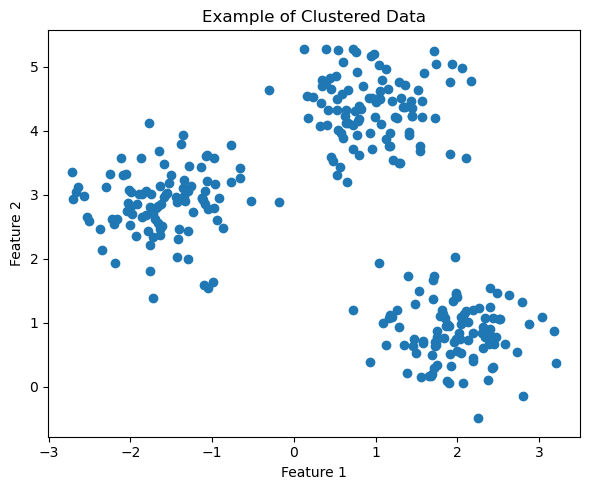

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic clustered data
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.5, random_state=0)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1])
plt.title("Example of Clustered Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.savefig("/Figures/clustering_example.pdf", dpi=300, bbox_inches="tight")

plt.show()

/Users/wa22abb/miniconda3/envs/mlp_test/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


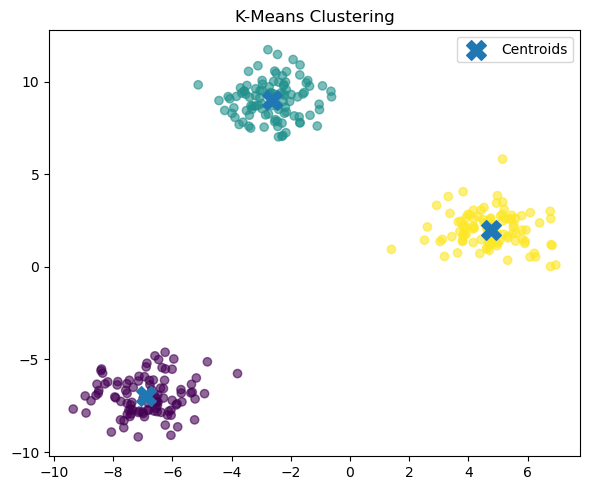

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate synthetic data
X, _ = make_blobs(n_samples=300, centers=3, random_state=0)

# Apply k-means
kmeans = KMeans(n_clusters=3, random_state=1)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# Plot results
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, alpha=0.6)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200, label="Centroids")
plt.title("K-Means Clustering")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/clustering_kmeans.pdf", dpi=300, bbox_inches="tight")

plt.show()

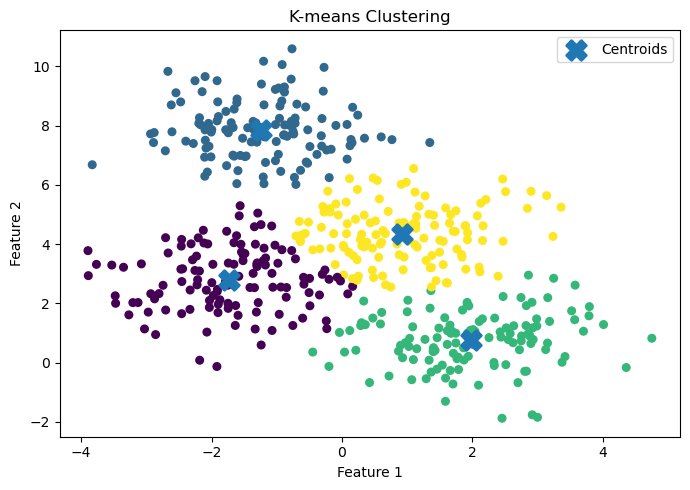

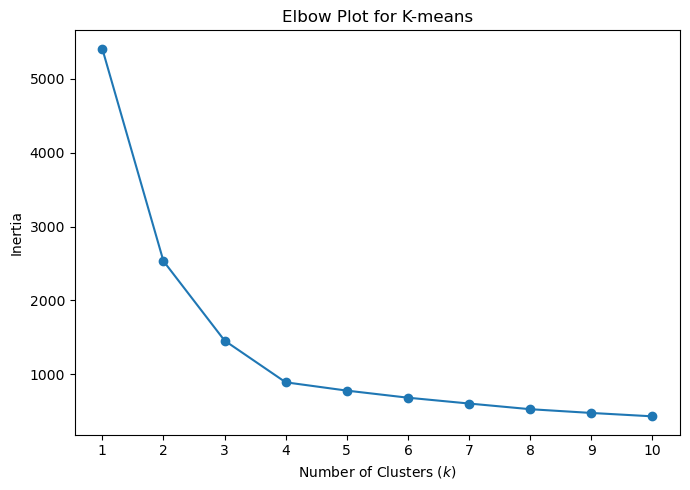

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate synthetic clustered data
X, _ = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.0,
    random_state=0
)

# Fit K-means with a chosen number of clusters
k = 4
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# Compute inertia values for the elbow plot
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=0, n_init=10)
    model.fit(X)
    inertias.append(model.inertia_)

# Plot clustered data
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    linewidths=2,
    label="Centroids"
)
plt.title("K-means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/clustering_kmeans_elbow1.pdf", dpi=300, bbox_inches="tight")

plt.show()

# Plot elbow curve
plt.figure(figsize=(7, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of Clusters ($k$)")
plt.ylabel("Inertia")
plt.title("Elbow Plot for K-means")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig("/Figures/clustering_kmeans_elbow2.pdf", dpi=300, bbox_inches="tight")

plt.show()

/Users/wa22abb/miniconda3/envs/mlp_test/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


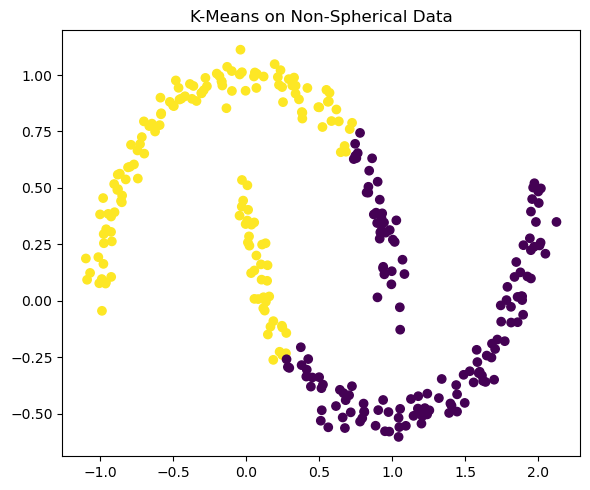

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# Generate non-spherical data
X, _ = make_moons(n_samples=300, noise=0.05, random_state=0)

# Apply k-means
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X)

# Plot result
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.title("K-Means on Non-Spherical Data")
plt.tight_layout()
plt.savefig("/Figures/kmeans_failure.pdf", dpi=300, bbox_inches="tight")

plt.show()

## Model Interpretability

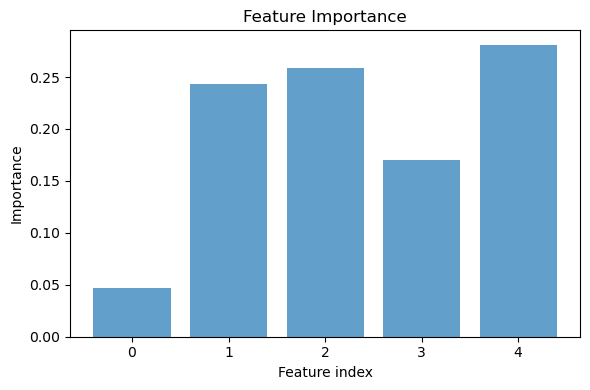

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Generate data
X, y = make_classification(n_samples=500, n_features=5, random_state=0)

# Train model
model = RandomForestClassifier(random_state=0)
model.fit(X, y)

# Feature importance
importance = model.feature_importances_

plt.figure(figsize=(6,4))
plt.bar(range(len(importance)), importance, alpha=0.7)
plt.xlabel("Feature index")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("/Figures/feature_importance.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
pip install shap

The figure layout has changed to tight


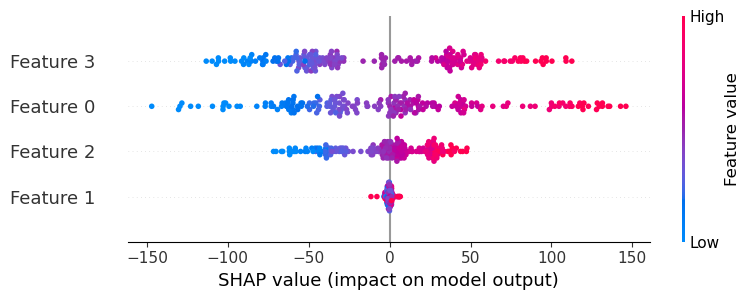

In [6]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

# Generate data
X, y = make_regression(n_samples=200, n_features=4, random_state=0)

# Train model
model = RandomForestRegressor()
model.fit(X, y)

# Compute SHAP values
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# Summary plot
shap.summary_plot(shap_values, X, show=False)

# Plot
plt.tight_layout()
plt.savefig("/Figures/shap.pdf", dpi=300, bbox_inches="tight")
plt.show()


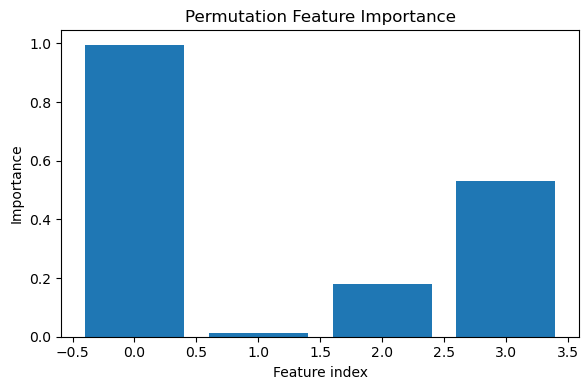

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.inspection import permutation_importance

# Generate data
X, y = make_regression(n_samples=300, n_features=4, random_state=0)

# Train model
model = RandomForestRegressor(random_state=0)
model.fit(X, y)

# Compute permutation importance
result = permutation_importance(model, X, y, n_repeats=10, random_state=0)

importance = result.importances_mean

# Plot
plt.figure(figsize=(6,4))
plt.bar(range(len(importance)), importance, alpha=0.7)
plt.xlabel("Feature index")
plt.ylabel("Importance")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()


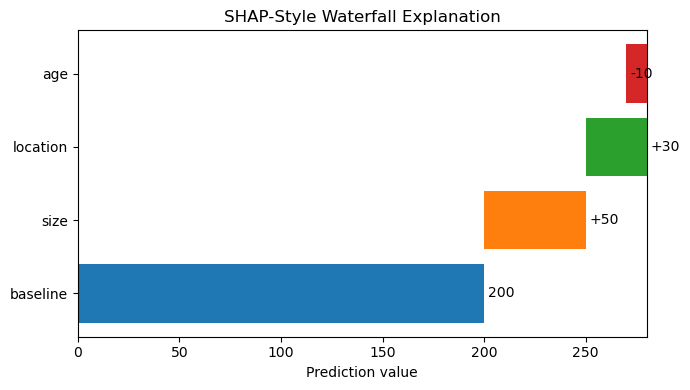

In [8]:
import matplotlib.pyplot as plt

# Example contributions
baseline = 200
features = ["size", "location", "age"]
contributions = [50, 30, -10]

# Compute cumulative values
values = [baseline]
for c in contributions:
    values.append(values[-1] + c)

# Plot
plt.figure(figsize=(7,4))

# Plot baseline
plt.barh(0, baseline)
plt.text(baseline + 2, 0, f"{baseline}", va='center')

# Plot contributions
for i, (feat, contrib) in enumerate(zip(features, contributions), start=1):
    prev = values[i-1]
    plt.barh(i, contrib, left=prev)
    plt.text(prev + contrib + 2, i, f"{contrib:+}", va='center')

# Labels
plt.yticks(range(len(features)+1), ["baseline"] + features)
plt.xlabel("Prediction value")
plt.title("SHAP-Style Waterfall Explanation")

plt.tight_layout()
plt.show()
